# SARID: Rainfall Intensity — Experiments
## Different features (MFCC / Mel / STFT) and models (Transformer / CNN / LSTM)

**Based on** `rain_regression_paper.ipynb`. Change **FEATURE_TYPE** and **MODEL_TYPE** below to try combinations and improve results.

| Feature | Paper R² (Transformer) |
|---------|------------------------|
| MFCC    | **0.765** (best)      |
| Mel     | 0.659                 |
| STFT    | 0.636                 |

## 1. Setup and imports

In [61]:
try:
    import torch
except ModuleNotFoundError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "torch", "numpy", "pandas", "matplotlib", "librosa", "tqdm", "scikit-learn"])
    print("Packages installed. Restart kernel and run again.")
    raise SystemExit(0)

import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import librosa
from tqdm.notebook import tqdm
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
torch.manual_seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

Device: cuda


## 2. Paths and experiment config

In [62]:
SARID_DIR = "/home/amani/phd/rain_detection/SARID"
TRAIN_DIR = os.path.join(SARID_DIR, "split/audio_without_background_split_nocoverage_train")
TEST_DIR = os.path.join(SARID_DIR, "split/audio_without_background_split_nocoverage_test")

TARGET_FRAMES = 173
SR = 22050
DURATION_SEC = 4

# Parallel data loading: 2–4 workers speed up training (set 0 if you get multiprocessing errors)
NUM_WORKERS = 2

# ============ CHANGE THESE TO EXPERIMENT ============
FEATURE_TYPE = 'mfcc'   # 'mfcc' | 'mel' | 'stft'
MODEL_TYPE = 'transformer'  # 'transformer' | 'cnn' | 'lstm'
# ==================================================

if FEATURE_TYPE == 'stft':
    FEATURE_DIM = 513  # 1024//2 + 1
else:
    FEATURE_DIM = 128

print(f"Feature: {FEATURE_TYPE}, dim={FEATURE_DIM} | Model: {MODEL_TYPE}")

Feature: mfcc, dim=128 | Model: transformer


## 3. Parse filename → rainfall intensity

In [63]:
def parse_rainfall_intensity(filename):
    if not filename.endswith('.mp3'):
        return None
    try:
        name = filename.replace('.mp3', '').strip()
        if '_segment' in name: name = name.split('_segment')[0]
        if '_cut[' in name: name = name.split('_cut[')[0]
        parts = name.split('_')
        return float(parts[1]) if len(parts) >= 2 else None
    except (ValueError, IndexError):
        return None

## 4. Feature extraction (MFCC / Mel / STFT)

In [64]:
def extract_mfcc(audio_path, n_mfcc=128, target_frames=173, sr=22050):
    try:
        y, sr = librosa.load(audio_path, sr=sr, duration=DURATION_SEC)
        y = librosa.util.normalize(y)
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc, n_fft=2048, hop_length=512)
        mfcc = librosa.util.normalize(mfcc)
        T = mfcc.shape[1]
        if T < target_frames:
            mfcc = np.pad(mfcc, ((0, 0), (0, target_frames - T)), mode='constant', constant_values=0)
        else:
            mfcc = mfcc[:, :target_frames]
        return mfcc.astype(np.float32)
    except Exception:
        return None

def extract_mel(audio_path, n_mels=128, target_frames=173, sr=22050):
    try:
        y, sr = librosa.load(audio_path, sr=sr, duration=DURATION_SEC)
        y = librosa.util.normalize(y)
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels, n_fft=2048, hop_length=512)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        mel_db = librosa.util.normalize(mel_db)
        T = mel_db.shape[1]
        if T < target_frames:
            mel_db = np.pad(mel_db, ((0, 0), (0, target_frames - T)), mode='constant', constant_values=0)
        else:
            mel_db = mel_db[:, :target_frames]
        return mel_db.astype(np.float32)
    except Exception:
        return None

def extract_stft(audio_path, n_fft=1024, target_frames=173, sr=22050):
    try:
        y, sr = librosa.load(audio_path, sr=sr, duration=DURATION_SEC)
        y = librosa.util.normalize(y)
        stft = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=512))
        stft_db = librosa.amplitude_to_db(stft, ref=np.max)
        stft_db = librosa.util.normalize(stft_db)
        T = stft_db.shape[1]
        if T < target_frames:
            stft_db = np.pad(stft_db, ((0, 0), (0, target_frames - T)), mode='constant', constant_values=0)
        else:
            stft_db = stft_db[:, :target_frames]
        return stft_db.astype(np.float32)
    except Exception:
        return None

def extract_features(audio_path, feature_type=FEATURE_TYPE, target_frames=TARGET_FRAMES):
    if feature_type == 'mfcc':
        return extract_mfcc(audio_path, n_mfcc=FEATURE_DIM, target_frames=target_frames)
    elif feature_type == 'mel':
        return extract_mel(audio_path, n_mels=FEATURE_DIM, target_frames=target_frames)
    else:
        return extract_stft(audio_path, n_fft=1024, target_frames=target_frames)

train_files = [f for f in os.listdir(TRAIN_DIR) if f.endswith('.mp3')]
sample_path = os.path.join(TRAIN_DIR, train_files[0])
feat = extract_features(sample_path)
print(f"Feature shape: {feat.shape} (expected: ({FEATURE_DIM}, {TARGET_FRAMES}))")

Feature shape: (128, 173) (expected: (128, 173))


## 5. Build metadata and dataset

In [65]:
def build_meta(audio_dir):
    files = [f for f in os.listdir(audio_dir) if f.endswith('.mp3')]
    meta = []
    for f in files:
        ri = parse_rainfall_intensity(f)
        if ri is not None:
            meta.append({'filename': f, 'rainfall_intensity': ri})
    return pd.DataFrame(meta)

train_meta = build_meta(TRAIN_DIR)
test_meta = build_meta(TEST_DIR)
print(f"Train: {len(train_meta)}, Test: {len(test_meta)}")

Train: 8441, Test: 3625


In [66]:
class SARIDDataset(Dataset):
    def __init__(self, meta_df, audio_dir, feature_type, feature_dim, target_frames):
        self.meta = meta_df.reset_index(drop=True)
        self.audio_dir = audio_dir
        self.feature_type = feature_type
        self.feature_dim = feature_dim
        self.target_frames = target_frames

    def __len__(self):
        return len(self.meta)

    def __getitem__(self, idx):
        row = self.meta.iloc[idx]
        path = os.path.join(self.audio_dir, row['filename'])
        feat = extract_features(path, self.feature_type, self.target_frames)
        if feat is None:
            feat = np.zeros((self.feature_dim, self.target_frames), dtype=np.float32)
        ri = np.float32(row['rainfall_intensity'])
        # (T, C) for Transformer/LSTM; CNN will transpose to (C, T)
        return torch.from_numpy(feat.T), torch.tensor(ri, dtype=torch.float32)

train_ds = SARIDDataset(train_meta, TRAIN_DIR, FEATURE_TYPE, FEATURE_DIM, TARGET_FRAMES)
test_ds = SARIDDataset(test_meta, TEST_DIR, FEATURE_TYPE, FEATURE_DIM, TARGET_FRAMES)
BATCH_SIZE = 256
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=(device.type=='cuda'))

## 6. Models: Transformer / CNN / LSTM

In [67]:
class TransformerRI(nn.Module):
    def __init__(self, d_model, nhead=4, num_layers=4, dim_feedforward=512, dropout=0.1):
        super().__init__()
        self.encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True, activation='relu')
        self.transformer = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(nn.Linear(d_model, 128), nn.ReLU(), nn.Linear(128, 1))

    def forward(self, x):
        out = self.transformer(x)
        out = out.transpose(1, 2)
        out = self.gap(out).squeeze(-1)
        return self.fc(out)

class CNNRI(nn.Module):
    def __init__(self, in_channels, seq_len=173):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(in_channels, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.2),
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(), nn.MaxPool1d(2), nn.Dropout(0.2),
            nn.Conv1d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.ReLU(), nn.AdaptiveAvgPool1d(1))
        self.fc = nn.Sequential(nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, 1))

    def forward(self, x):
        x = x.transpose(1, 2)
        out = self.conv(x).squeeze(-1)
        return self.fc(out)

class LSTMRI(nn.Module):
    def __init__(self, input_size, hidden_size=256, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True, dropout=dropout)
        self.fc = nn.Sequential(nn.Linear(hidden_size, 128), nn.ReLU(), nn.Dropout(0.3), nn.Linear(128, 1))

    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        return self.fc(out)

def build_model():
    if MODEL_TYPE == 'transformer':
        return TransformerRI(d_model=FEATURE_DIM).to(device)
    elif MODEL_TYPE == 'cnn':
        return CNNRI(in_channels=FEATURE_DIM, seq_len=TARGET_FRAMES).to(device)
    else:
        return LSTMRI(input_size=FEATURE_DIM).to(device)

model = build_model()
print(f"Model: {MODEL_TYPE}, params: {sum(p.numel() for p in model.parameters()):,}")

Model: transformer, params: 1,008,001


## 7. Training config and loop

In [68]:
NUM_EPOCHS = 100
warmup_epochs = 5
init_lr = 5e-4
min_lr = 1e-6

def get_lr(epoch, num_epochs, warmup_epochs=5, init_lr=5e-4, min_lr=1e-6):
    if epoch < warmup_epochs:
        return init_lr * (epoch + 1) / warmup_epochs
    progress = (epoch - warmup_epochs) / (num_epochs - warmup_epochs)
    return min_lr + 0.5 * (init_lr - min_lr) * (1 + np.cos(np.pi * progress))

criterion = nn.SmoothL1Loss()
optimizer = torch.optim.Adam(model.parameters(), lr=init_lr, weight_decay=1e-5)

def evaluate(model, loader):
    model.eval()
    preds, gts = [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            out = model(x).squeeze(-1)
            preds.append(out.cpu().numpy())
            gts.append(y.numpy())
    preds = np.concatenate(preds)
    gts = np.concatenate(gts)
    return mean_absolute_error(gts, preds), np.sqrt(mean_squared_error(gts, preds)), r2_score(gts, preds)

history = {'train_loss': [], 'mae': [], 'rmse': [], 'r2': []}
best_r2 = -np.inf

In [ ]:
for epoch in range(NUM_EPOCHS):
    lr = get_lr(epoch, NUM_EPOCHS, warmup_epochs)
    for g in optimizer.param_groups:
        g['lr'] = lr
    model.train()
    train_loss = 0.0
    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS}", leave=True):
        x, y = x.to(device), y.to(device).unsqueeze(1)
        optimizer.zero_grad()
        loss = criterion(model(x), y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    history['train_loss'].append(train_loss)
    mae, rmse, r2 = evaluate(model, test_loader)
    history['mae'].append(mae)
    history['rmse'].append(rmse)
    history['r2'].append(r2)
    if r2 > best_r2:
        best_r2 = r2
        torch.save(model.state_dict(), f'best_{FEATURE_TYPE}_{MODEL_TYPE}.pth')
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Loss: {train_loss:.4f} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R²: {r2:.4f}", flush=True)

Epoch 1/100 | Loss: 0.8844 | MAE: 1.1249 | RMSE: 1.7311 | R²: 0.0902


Epoch 2/100:  12%|█▏        | 4/33 [00:31<03:14,  6.71s/it]Epoch 2/100:  18%|█▊        | 6/33 [00:50<03:27,  7.68s/it]

## 8. Load best and report

In [ ]:
model.load_state_dict(torch.load(f'best_{FEATURE_TYPE}_{MODEL_TYPE}.pth', weights_only=True))
mae, rmse, r2 = evaluate(model, test_loader)
print("="*55)
print(f"Best result — Feature: {FEATURE_TYPE} | Model: {MODEL_TYPE}")
print("="*55)
print(f"  MAE:  {mae:.4f} mm h⁻¹")
print(f"  RMSE: {rmse:.4f} mm h⁻¹")
print(f"  R²:   {r2:.4f}")
print("="*55)

/tmp/ipykernel_300433/1562618477.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(f'best_{FEATURE_TYPE}_{MODEL_TYPE}.pth', weights_only=T

## 9. Visualise test results (understand the metrics)

- **Scatter**: each point = one test clip. If predictions were perfect, all points would lie on the red line.
- **R²**: points close to the line → high R²; points scattered far from the line → low R².
- **MAE**: average distance of points to the line (vertical). **RMSE**: same idea but large errors count more.
- **Error histogram**: distribution of (predicted − true). MAE ≈ average of |errors|; RMSE ≈ typical size including big mistakes.

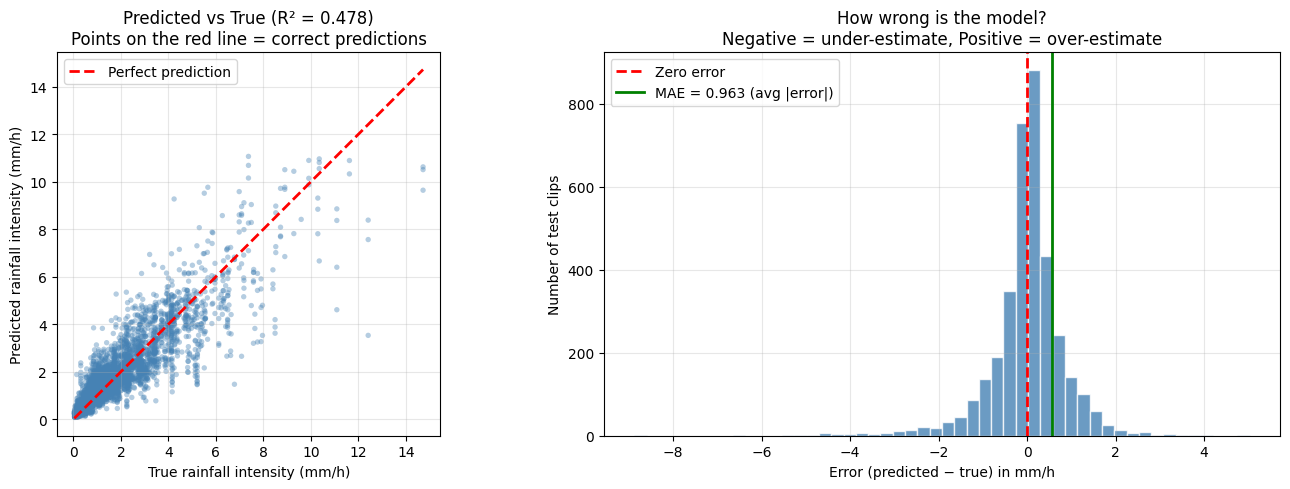

MAE = 0.9630 → on average, predictions are off by 0.96 mm/h.
RMSE = 1.2925 → large errors pull this up; RMSE > MAE means some clips have big errors.
R² = 0.4775 → model explains 47.8% of the variation in rainfall intensity.


In [20]:
import matplotlib.pyplot as plt

model.eval()
preds_list, gts_list = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        out = model(x).squeeze(-1).cpu().numpy()
        preds_list.append(out)
        gts_list.append(y.numpy())
preds = np.concatenate(preds_list)
gts = np.concatenate(gts_list)
errors = preds - gts

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Predicted vs True (scatter)
ax1 = axes[0]
ax1.scatter(gts, preds, alpha=0.4, s=15, c='steelblue', edgecolors='none')
mx = max(gts.max(), preds.max())
mn = min(gts.min(), preds.min())
ax1.plot([mn, mx], [mn, mx], 'r--', lw=2, label='Perfect prediction')
ax1.set_xlabel('True rainfall intensity (mm/h)')
ax1.set_ylabel('Predicted rainfall intensity (mm/h)')
ax1.set_title(f'Predicted vs True (R² = {r2:.3f})\nPoints on the red line = correct predictions')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)
ax1.set_aspect('equal', adjustable='box')

# 2. Distribution of errors (predicted - true)
ax2 = axes[1]
ax2.hist(errors, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax2.axvline(0, color='red', linestyle='--', lw=2, label='Zero error')
ax2.axvline(np.mean(np.abs(errors)), color='green', linestyle='-', lw=2, label=f'MAE = {mae:.3f} (avg |error|)')
ax2.set_xlabel('Error (predicted − true) in mm/h')
ax2.set_ylabel('Number of test clips')
ax2.set_title('How wrong is the model?\nNegative = under-estimate, Positive = over-estimate')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"MAE = {mae:.4f} → on average, predictions are off by {mae:.2f} mm/h.")
print(f"RMSE = {rmse:.4f} → large errors pull this up; RMSE > MAE means some clips have big errors.")
print(f"R² = {r2:.4f} → model explains {r2*100:.1f}% of the variation in rainfall intensity.")